# LOCAL_KO_EN_XLSX_G1_SANITIZED — G1 Sanitized Raw EDA

Status: **G1 SANITIZED SUPPORT / PRE-INGESTION EDA / NOT QC ACCEPTANCE**

이 notebook은 old EDA branch의 notebook/blob을 복사하지 않고 local raw에서 aggregate를 새로 계산한다.
원문 문장, preview, URL, pair ID, text hash를 출력하거나 저장하지 않는다.

## 1. Safety and execution contract

- Full-population aggregate profiling
- Raw roots are read-only
- No tokenization, morphology, model fitting, inferential claim, or automatic exclusion
- No raw sentence/example output

In [1]:
from pathlib import Path
import json, os, sys
import pandas as pd
from IPython.display import Markdown, display

def discover_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/tokenization_premium").is_dir():
            return candidate
    raise RuntimeError(f"Tokenization_Premium checkout not found from {start}")

DISCOVERED_PROJECT_ROOT = discover_project_root()
sys.path.insert(0, str(DISCOVERED_PROJECT_ROOT / "src"))
from tokenization_premium.paths import PROJECT_ROOT
assert PROJECT_ROOT.resolve() == DISCOVERED_PROJECT_ROOT.resolve()

RAW_ROOT = Path(os.environ.get("TOKENIZATION_PREMIUM_RAW_ROOT", '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub')).expanduser().resolve()
SUPPORT_DIR = PROJECT_ROOT / "outputs/eda_raw/g1_support/support"
sys.path.insert(0, str(SUPPORT_DIR))

from sanitized_raw_eda import profile_dataset, save_profile, plot_profile, targeted_legacy

CONFIG = {'dataset_local_id': 'LOCAL_KO_EN_XLSX_G1_SANITIZED', 'artifact_prefix': 'legacy_ko_en_g1', 'kind': 'xlsx', 'raw_relative_dir': '한국어-영어 번역(병렬) 말뭉치'}
CONFIG["raw_root"] = str(RAW_ROOT / CONFIG.pop("raw_relative_dir"))
OUTPUT_DIR = PROJECT_ROOT / "outputs/eda_raw/g1_support" / CONFIG["artifact_prefix"]
FIGURE_DIR = PROJECT_ROOT / "outputs/figures/eda_raw/g1_support" / CONFIG["artifact_prefix"]
TARGET_OUTPUT_DIR = OUTPUT_DIR / "targeted"
TARGET_FIGURE_DIR = FIGURE_DIR / "targeted"

print("project root: CURRENT_CHECKOUT")
print("raw root:", RAW_ROOT)
print("dataset:", CONFIG["dataset_local_id"])
print("population: FULL_POPULATION_AGGREGATES")
print("raw text export: 0")


project root: CURRENT_CHECKOUT
raw root: /home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub
dataset: LOCAL_KO_EN_XLSX_G1_SANITIZED
population: FULL_POPULATION_AGGREGATES
raw text export: 0


## 2. Full-population sanitized profile

findfont: Failed to find font weight bold, now using 600.


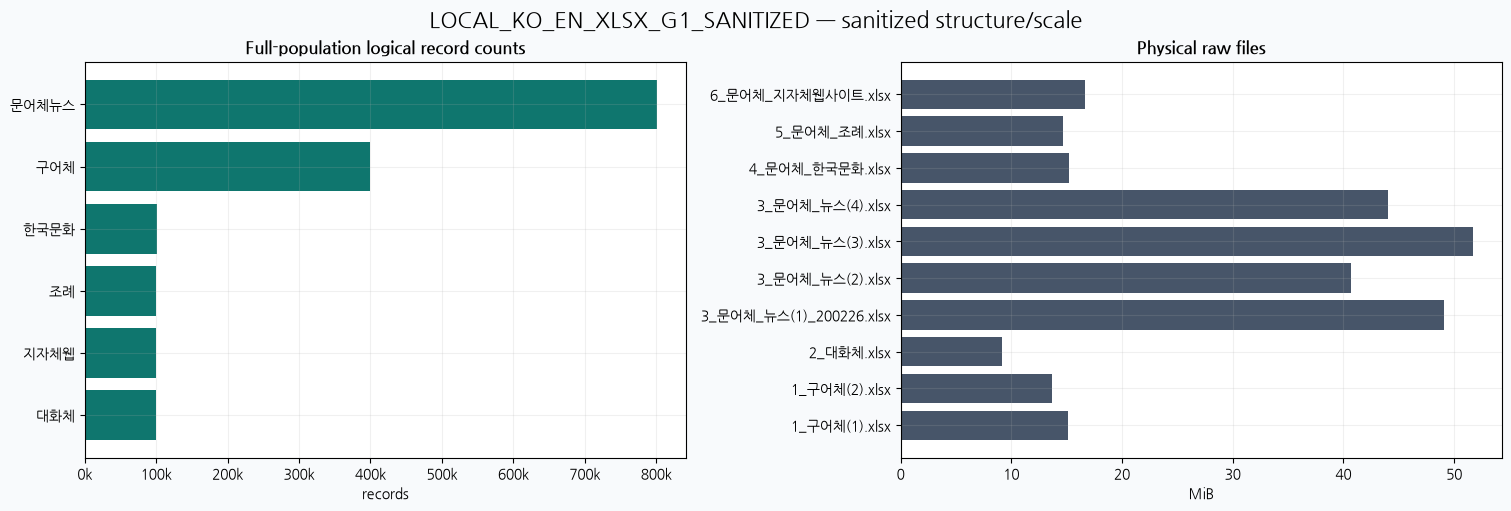

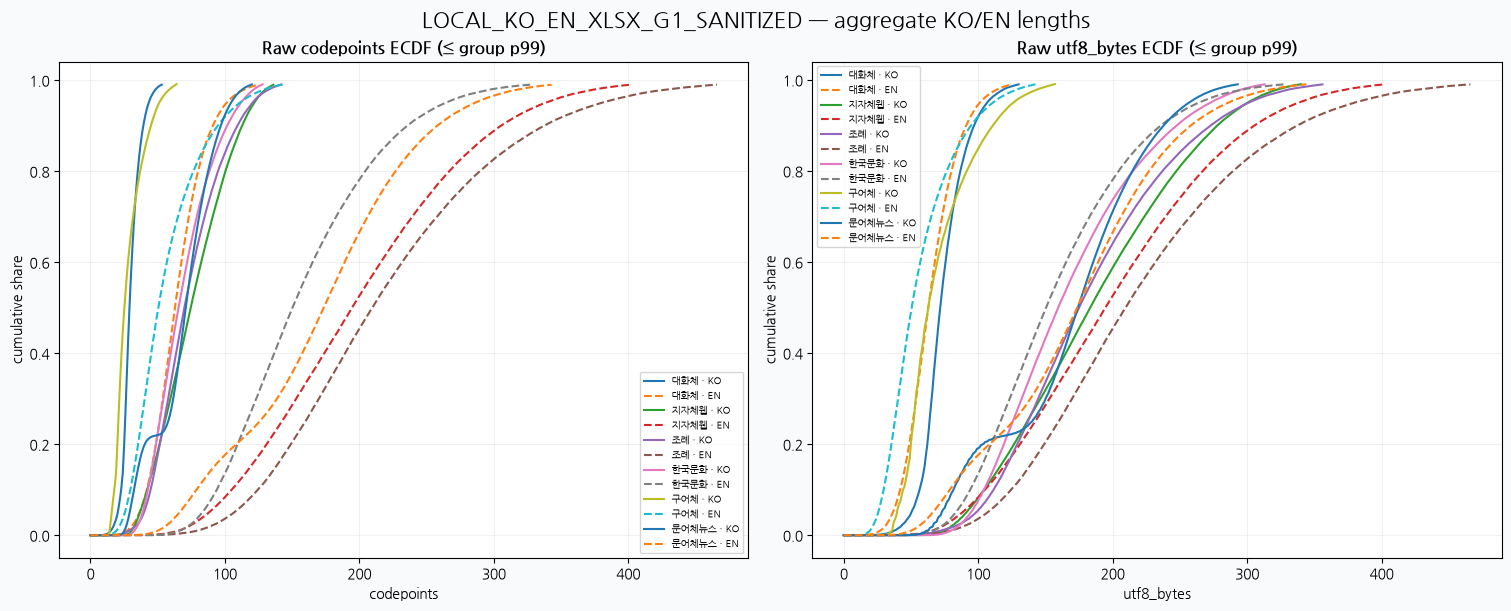

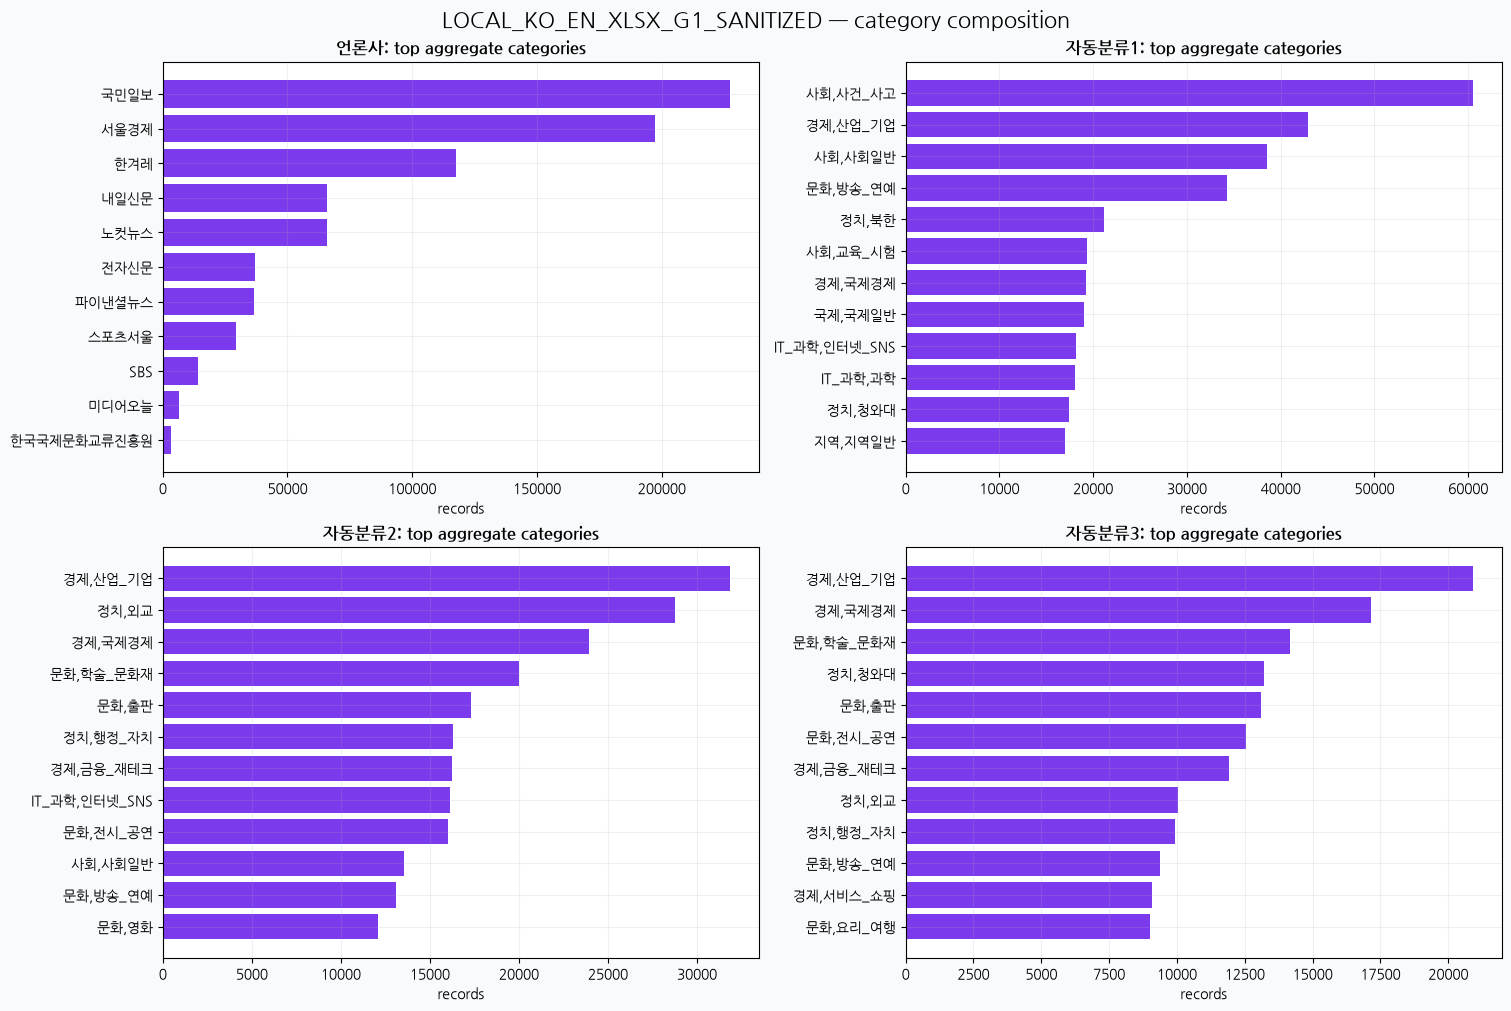

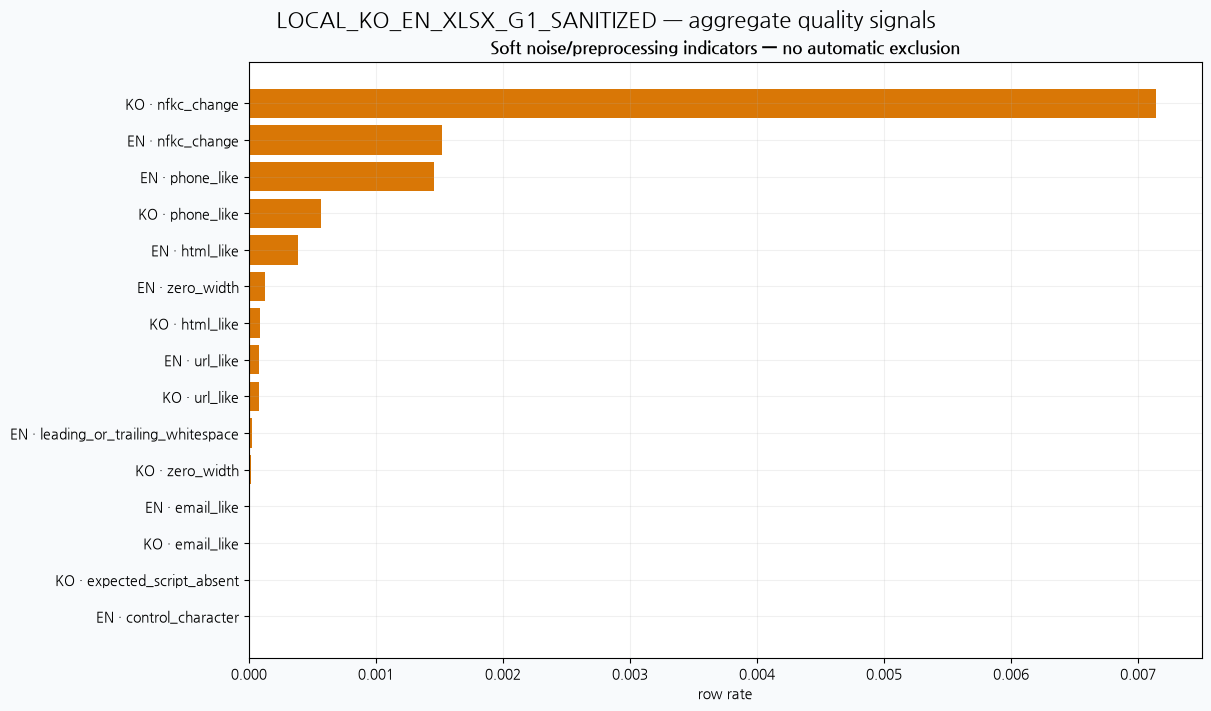

,dataset_local_id,audit_timestamp,audit_completed_timestamp,physical_file_count,profiled_data_file_count,logical_record_count,population_scope,raw_text_exported,text_hash_exported,status
0,LOCAL_KO_EN_XLSX_G1_SANITIZED,2026-08-16T17:28:04+09:00,2026-08-16T17:29:45+09:00,10,10,1602418,FULL_POPULATION_AGGREGATES,False,False,G1_SANITIZED_SUPPORT / NOT QC ACCEPTANCE


,group,records
0,구어체,400000
1,대화체,100000
2,문어체뉴스,801387
3,조례,100298
4,지자체웹,100087
5,한국문화,100646


In [2]:
result = profile_dataset(CONFIG)
profile_paths = save_profile(result, OUTPUT_DIR)
figure_paths = plot_profile(result, FIGURE_DIR)
display(pd.DataFrame([result["summary"]]))
display(result["record_counts"])


## 3. Aggregate structure, length, category, and soft flags

모든 표는 keys, counts, rates, lengths, categories만 포함한다.

In [3]:
display(Markdown("### Schema: keys/types/missingness only"))
display(result["schema"].sort_values(["group", "missing_or_empty_rate"], ascending=[True, False]))
display(Markdown("### Length summaries: aggregate only"))
display(result["length_summary"])
display(Markdown("### Non-sensitive category distributions"))
display(result["categories"].sort_values(["dimension", "record_count"], ascending=[True, False]).groupby("dimension").head(20))
display(Markdown("### Soft noise and duplicate candidates"))
display(result["noise"].sort_values("rate", ascending=False).head(40))
display(result["duplicates"])


### Schema: keys/types/missingness only

,group,field,records,absent,null,empty,missing_or_empty_rate,type_counts,raw_value_exported
0,구어체,SID,400000,0,0,0,0.000000,"{""integer"": 200000, ""number"": 200000}",False
1,구어체,번역문,400000,0,0,0,0.000000,"{""string"": 400000}",False
2,구어체,원문,400000,0,0,0,0.000000,"{""string"": 400000}",False
3,대화체,Set Nr.,100000,0,0,0,0.000000,"{""integer"": 100000}",False
4,대화체,대분류,100000,0,0,0,0.000000,"{""string"": 100000}",False
5,대화체,발화자,100000,0,0,0,0.000000,"{""string"": 100000}",False
6,대화체,번역문,100000,0,0,0,0.000000,"{""string"": 100000}",False
7,대화체,상황,100000,0,0,0,0.000000,"{""string"": 100000}",False
8,대화체,소분류,100000,0,0,0,0.000000,"{""string"": 100000}",False
9,대화체,원문,100000,0,0,0,0.000000,"{""string"": 100000}",False


### Length summaries: aggregate only

,group,language,metric,count,min,p50,p90,p95,p99,max,mean
0,구어체,EN,codepoints,400000,10,51,95,111,143,312,57.613825
1,구어체,EN,utf8_bytes,400000,10,51,95,111,143,312,57.633545
2,구어체,KO,codepoints,400000,4,26,45,52,64,117,29.081320
3,구어체,KO,utf8_bytes,400000,10,63,111,126,157,269,71.497820
4,대화체,EN,codepoints,100000,10,63,92,102,125,332,65.610120
5,대화체,EN,utf8_bytes,100000,10,63,92,102,125,332,65.638910
6,대화체,KO,codepoints,100000,5,29,40,44,53,162,30.693080
7,대화체,KO,utf8_bytes,100000,13,72,97,107,130,384,75.101610
8,문어체뉴스,EN,codepoints,801387,20,174,258,286,343,706,173.244872
9,문어체뉴스,EN,utf8_bytes,801387,20,174,259,286,344,706,173.382809


### Non-sensitive category distributions

,group,dimension,category,record_count
160,대화체,대분류,여행/쇼핑,46524
0,대화체,대분류,비즈니스,28064
7,대화체,대분류,일상대화,24012
141,대화체,대분류,스포츠,1000
131,대화체,대분류,의학,400
...,...,...,...,...
3129,한국문화,키워드,역사/근현대|정치·경제·사회/정치·행정,241
3136,한국문화,키워드,구비 전승·언어·문학,238
3147,한국문화,키워드,역사/근현대|생활·민속/생활,133
3170,한국문화,키워드,역사/근현대|문화유산/기록 유산,122


### Soft noise and duplicate candidates

,group,language,metric,row_count,records,rate,classification
50,지자체웹,KO,nfkc_change,1170,100087,0.011690,SOFT_OBSERVATION_ONLY
39,조례,KO,nfkc_change,1116,100298,0.011127,SOFT_OBSERVATION_ONLY
29,문어체뉴스,KO,nfkc_change,8028,801387,0.010018,SOFT_OBSERVATION_ONLY
61,한국문화,KO,nfkc_change,954,100646,0.009479,SOFT_OBSERVATION_ONLY
56,한국문화,EN,phone_like,721,100646,0.007164,SOFT_OBSERVATION_ONLY
55,한국문화,EN,nfkc_change,513,100646,0.005097,SOFT_OBSERVATION_ONLY
62,한국문화,KO,phone_like,271,100646,0.002693,SOFT_OBSERVATION_ONLY
22,문어체뉴스,EN,nfkc_change,1614,801387,0.002014,SOFT_OBSERVATION_ONLY
36,조례,EN,phone_like,180,100298,0.001795,SOFT_OBSERVATION_ONLY
23,문어체뉴스,EN,phone_like,1202,801387,0.001500,SOFT_OBSERVATION_ONLY


,scope,records,duplicate_pair_rows_after_first,distinct_duplicate_pair_groups,method,classification
0,local_dataset,1602418,2494,2494,salted in-memory BLAKE2b-128 exact raw KO+EN; ...,DUPLICATE_CANDIDATE_ONLY


## 4. Targeted decision evidence

News2↔Culture exact-pair overlap, multiplicity, and aggregate metadata concentration under POTENTIAL_CORPUS_COMPOSITION_OVERLAP.

모든 결과는 structural/local observation이며 causal, exclusion, Tier, QC acceptance 판단이 아니다.

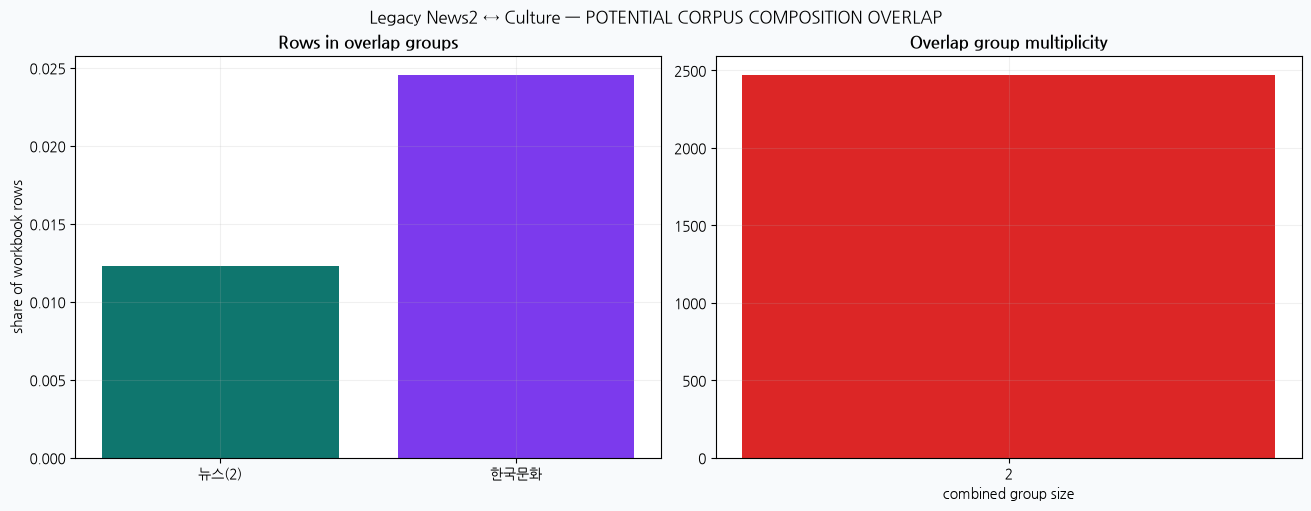

### news2_culture_overlap_summary

,overlap_exact_pair_group_count,one_to_one_matchable_overlap_count,news2_total_rows,news2_rows_in_overlap_groups,news2_overlap_row_rate,culture_total_rows,culture_rows_in_overlap_groups,culture_overlap_row_rate,classification
0,2469,2469,200541,2469,0.012312,100646,2469,0.024532,POTENTIAL_CORPUS_COMPOSITION_OVERLAP


### news2_culture_overlap_multiplicity

,news2_group_multiplicity,culture_group_multiplicity,combined_group_multiplicity,exact_pair_group_count
0,1,1,2,2469


### news2_culture_overlap_metadata_distribution

,corpus,metadata_field,category,overlap_row_count
10,CULTURE,키워드,문화·교육/문화·예술,2434
12,CULTURE,키워드,문화·교육/문화·예술|정치·경제·사회/사회·복지,16
14,CULTURE,키워드,문화·교육/문화·예술|정치·경제·사회/경제·산업,11
11,CULTURE,키워드,문화·교육/문화·예술|정체·경제·사회/사회·복지,4
15,CULTURE,키워드,문화·교육/교육|문화·교육/문화·예술,3
13,CULTURE,키워드,문화·교육/문화·예술|문화·교육/교육,1
0,NEWS2,날짜,20190906,2469
4,NEWS2,언론사,한국국제문화교류진흥원,2469
1,NEWS2,자동분류1,문화·교육/문화·예술,2434
6,NEWS2,자동분류1,문화·교육/문화·예술|정치·경제·사회/사회·복지,16


### news2_culture_overlap_concentration

,corpus,metadata_field,overlap_rows_with_field,unique_category_count,top1_share,top5_share,top10_share,classification
0,CULTURE,키워드,2469,6,0.985824,0.999595,1.0,DESCRIPTIVE_CONCENTRATION_ONLY
1,NEWS2,날짜,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE_CONCENTRATION_ONLY
2,NEWS2,언론사,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE_CONCENTRATION_ONLY
3,NEWS2,자동분류1,2469,6,0.985824,0.999595,1.0,DESCRIPTIVE_CONCENTRATION_ONLY
4,NEWS2,자동분류2,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE_CONCENTRATION_ONLY
5,NEWS2,자동분류3,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE_CONCENTRATION_ONLY


In [4]:
targeted = targeted_legacy(Path(CONFIG['raw_root']), TARGET_OUTPUT_DIR, TARGET_FIGURE_DIR)
for name, frame in targeted.items():
    display(Markdown(f"### {name}"))
    display(frame)


## 5. Interpretation scaffold

관찰:

원인 후보:

제한: local raw aggregate이며 official identity/provenance를 확정하지 않는다.

결론: Research Director reconciliation 전에는 source rank, exclusion, Tier를 결정하지 않는다.

## 6. Export validation

In [5]:
required = profile_paths + figure_paths
for path in required:
    assert path.exists(), path
for frame_name in ["inventory", "record_counts", "schema", "length_summary", "noise", "categories", "duplicates"]:
    frame = result[frame_name]
    assert not {"ko", "en", "ko_preview", "en_preview", "원문", "번역문", "URL"}.intersection(frame.columns)
assert result["summary"]["raw_text_exported"] is False
assert result["summary"]["text_hash_exported"] is False
print("SANITIZED NOTEBOOK PASS")
print("raw text rows exported: 0")
print("text hashes exported: 0")


SANITIZED NOTEBOOK PASS
raw text rows exported: 0
text hashes exported: 0
